<a href="https://colab.research.google.com/github/Fares-pr0g/ML-journey-ep-2-Experimenting-with-NN-s-in-PyTorch/blob/main/Learning_PyTorch_04_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimenting to improve CNN accuracy

In [1]:
import torch
from torch import nn
import torchvision

import matplotlib.pyplot as plt

In [2]:

device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:

import requests
import zipfile
from pathlib import Path

# Let's setup the path to data folder
data_path= Path("data/")
image_path= data_path / "pizza_steak_sushi"

# Does the folder exist? If not, download it
if image_path.is_dir():
  print(f"{image_path} directory exists.")
else:
  print(f"Did not find {image_path} directory, creating one...")
  image_path.mkdir(parents= True, exist_ok= True)

  # Download pizza, steak, sushi data
  with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading pizza, steak, sushi data...")
    f.write(request.content)

  # Unzip pizza, steak, sushi data
  with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi data...")
    zip_ref.extractall(image_path)

data/pizza_steak_sushi directory exists.


In [4]:

# setup training & testing paths
train = image_path / "train"
test = image_path / "test"

train, test

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [5]:

import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [6]:
# Simple transform: No data augmentation
simple_transform= transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

### Let's visualize some data (especially after transforms)

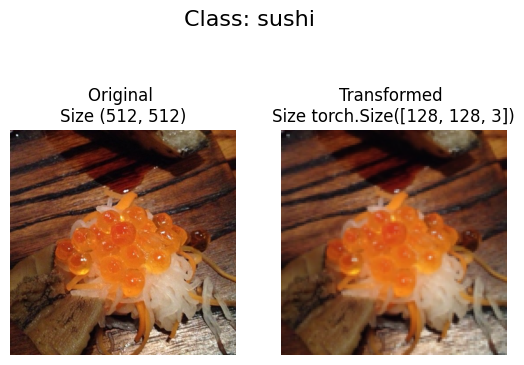

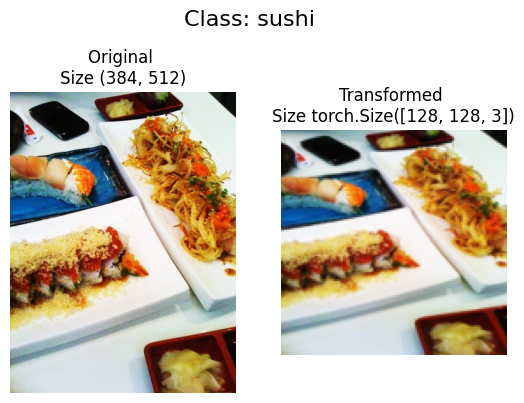

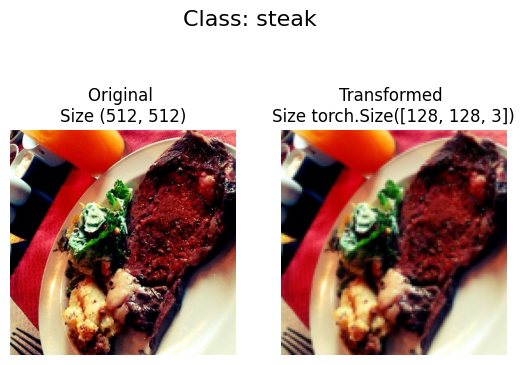

In [7]:
def plot_transformed_images(images_path: pathlib.Path, transform, n: int = 3, seed: int = 42):
  import random
  random.seed(42)
  images_path_list= list(images_path.glob("*/*/*.jpg"))
  random_images_path_list= random.sample(images_path_list, k=n)
  for image_path in random_images_path_list:
    fig, ax = plt.subplots(1,2)
    img= Image.open(image_path)
    img_transformed= transform(img).permute(1,2,0)
    ax[0].imshow(img)
    ax[0].set_title(f"Original \nSize {img.size}")
    ax[0].axis("off")
    ax[1].imshow(img_transformed)
    ax[1].set_title(f"Transformed \nSize {img_transformed.shape}")
    ax[1].axis("off")

    fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path, simple_transform)


In [8]:
# functionize data preprocessing
def data_preprocessing(parent_dir: Path, train_transform: transforms.Compose, test_transform: transforms.Compose):
  train_dir= parent_dir / "train"
  test_dir= parent_dir / "test"

  from torchvision import datasets
  train_data= datasets.ImageFolder(root=train_dir,
                                          transform=train_transform)
  test_data= datasets.ImageFolder(root=test_dir,
                                         transform=test_transform)
  import os
  from torch.utils.data import DataLoader

  BATCH_SIZE= 32
  NUM_WORKERS= os.cpu_count()

  print( f"Creating DataLoader with batch size {BATCH_SIZE} and {NUM_WORKERS} workers")

  train_dataloader= DataLoader(train_data, batch_size= BATCH_SIZE,
                               shuffle=True,
                               num_workers= NUM_WORKERS)
  test_dataloader= DataLoader(test_data, batch_size= BATCH_SIZE,
                               shuffle=False,
                               num_workers= NUM_WORKERS)
  return train_dataloader, test_dataloader, train_data, test_data



In [9]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer):
  model.train()
  train_loss, train_acc= 0,0
  for batch, (X,y) in enumerate(dataloader):
    X,y = X.to(device), y.to(device)
    optimizer.zero_grad()

    y_pred= model(X)
    loss= loss_fn(y_pred, y)
    train_loss+= loss.item()

    loss.backward()
    optimizer.step()

    y_pred_class= torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc+= (y_pred_class == y).sum().item()/len(y_pred)

  # Calculate and accumulate accuracy metrics across all batches
  train_loss= train_loss / len(dataloader)
  train_acc= train_acc / len(dataloader)
  return train_loss, train_acc*100

In [10]:
def test_step(model: torch.nn.Module,
              dataloader:torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
  model.eval()
  test_loss, test_acc= 0,0
  with torch.inference_mode():
    for batch, (X,y) in enumerate(dataloader):
      X,y = X.to(device), y.to(device)
      test_pred_logits= model(X)
      loss= loss_fn(test_pred_logits,y)
      test_loss+=loss.item()

      test_pred_labels= torch.argmax(test_pred_logits, dim=1)
      test_acc+=(test_pred_labels == y).sum().item()/ len(y)

  test_loss /= len(dataloader)
  test_acc /= len(dataloader)

  return test_loss, test_acc*100

In [11]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer:torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int =5):

  # 2. Create empty results dictionary
  results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
  }
  for epoch in range(epochs):
    train_loss, train_acc= train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    test_loss, test_acc= test_step(model=model,
                                   dataloader= test_dataloader,
                                   loss_fn=loss_fn)
    if (epochs < 20) or (epoch %10== 0):
      print(
              f"{epochs//10}"
              f"Epoch: {epoch+1} | "
              f"train_loss: {train_loss:.4f} | "
              f"train_acc: {train_acc:.4f} | "
              f"test_loss: {test_loss:.4f} | "
              f"test_acc: {test_acc:.4f}"
          )


    # Ensure all data is moved to CPU and converted to float for storage
    results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
    results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
    results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
    results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
  return results


### Let's set the data augmentation transform

In [12]:
# We add the TrivialAugment to the training transform
transform_trivial_augment= transforms.Compose([
    transforms.Resize((128,128)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

In [13]:

train_dl, test_dl, train_data, test_data= data_preprocessing(image_path,
                                                                             train_transform= simple_transform,
                                                                              test_transform=simple_transform)

Creating DataLoader with batch size 32 and 2 workers


In [17]:
class Custom_CNN(nn.Module):

  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1= nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2) #default stride value is same as kernel_size
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.conv_block_3 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier= nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= hidden_units*16*16,
                  out_features= output_shape)
    )
  def forward(self, X: torch.Tensor):
    X= self.conv_block_1(X)
    X= self.conv_block_2(X)
    X= self.conv_block_3(X)
    X= self.classifier(X)
    return X

torch.manual_seed(42)
custom_model_01= Custom_CNN(input_shape=3, hidden_units=10,
                 output_shape= len(train_data.classes)).to(device)


In [18]:
# Let's get an idea on the shapes going through our model with torchinfo
!pip install torchinfo
import torchinfo

from torchinfo import summary
summary(custom_model_01, input_size=[32,3,128,128])

Layer (type:depth-idx)                   Output Shape              Param #
Custom_CNN                               [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 64, 64]          --
│    └─Conv2d: 2-1                       [32, 10, 128, 128]        280
│    └─ReLU: 2-2                         [32, 10, 128, 128]        --
│    └─Conv2d: 2-3                       [32, 10, 128, 128]        910
│    └─ReLU: 2-4                         [32, 10, 128, 128]        --
│    └─MaxPool2d: 2-5                    [32, 10, 64, 64]          --
├─Sequential: 1-2                        [32, 10, 32, 32]          --
│    └─Conv2d: 2-6                       [32, 10, 64, 64]          910
│    └─ReLU: 2-7                         [32, 10, 64, 64]          --
│    └─Conv2d: 2-8                       [32, 10, 64, 64]          910
│    └─ReLU: 2-9                         [32, 10, 64, 64]          --
│    └─MaxPool2d: 2-10                   [32, 10, 32, 32]          --
├─Sequentia

## Baseline model: without data augmentation

In [19]:

torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS= 100

#Setup loss funct. and optimizer
loss_fn= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(params=custom_model_01.parameters(), lr=3e-4)

from timeit import default_timer as timer
start_time= timer()

model_1_results= train(model=custom_model_01,
                       train_dataloader=train_dl,
                       test_dataloader=test_dl,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs= NUM_EPOCHS)

end_time= timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

10Epoch: 1 | train_loss: 1.0989 | train_acc: 42.5781 | test_loss: 1.1018 | test_acc: 26.0417
10Epoch: 11 | train_loss: 1.0889 | train_acc: 42.5781 | test_loss: 1.1227 | test_acc: 26.0417
10Epoch: 21 | train_loss: 1.0556 | train_acc: 54.2969 | test_loss: 1.0764 | test_acc: 30.0189
10Epoch: 31 | train_loss: 0.8192 | train_acc: 66.4062 | test_loss: 1.0053 | test_acc: 51.4205
10Epoch: 41 | train_loss: 0.8410 | train_acc: 58.5938 | test_loss: 1.0333 | test_acc: 43.3712
10Epoch: 51 | train_loss: 0.6639 | train_acc: 74.6094 | test_loss: 1.0853 | test_acc: 40.3409
10Epoch: 61 | train_loss: 0.5721 | train_acc: 79.6875 | test_loss: 1.1793 | test_acc: 45.3598
10Epoch: 71 | train_loss: 0.4243 | train_acc: 83.5938 | test_loss: 1.2441 | test_acc: 37.2159
10Epoch: 81 | train_loss: 0.4139 | train_acc: 85.9375 | test_loss: 1.4307 | test_acc: 41.3826
10Epoch: 91 | train_loss: 0.2649 | train_acc: 91.7969 | test_loss: 1.8241 | test_acc: 43.4659
Total training time: 134.830 seconds


In [20]:

def plot_loss_curves(results: Dict[str, List[float]]):
  loss= results['train_loss']
  test_loss= results['test_loss']

  acc= results["train_acc"]
  test_acc= results["test_acc"]

  epochs= range(len(results["train_loss"]))

  plt.figure(figsize=(15,7))

  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label='train_loss')
  plt.plot(epochs, test_loss, label='test_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(epochs, acc, label='train_accuracy')
  plt.plot(epochs, test_acc, label='test_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

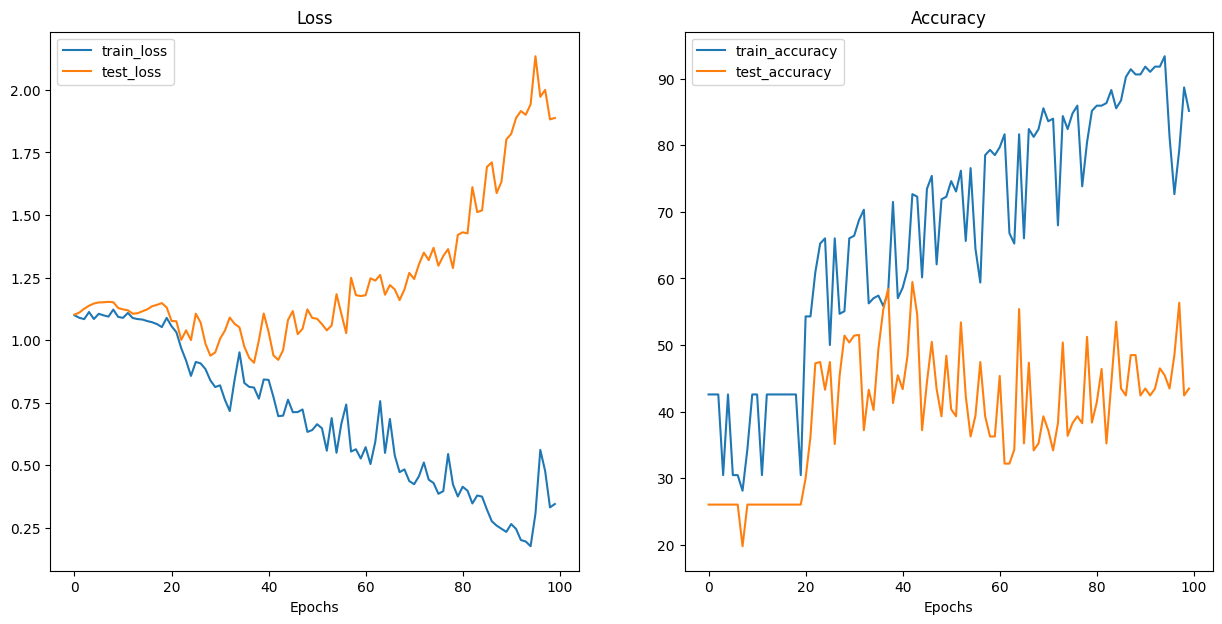

In [21]:
plot_loss_curves(model_1_results)

Okay, we upscaled the dimension size to 128x128, reduced the learning rate to 0.0003 and we got 95% training acc. But only 41% on testing acc -> That's clearly overfitting and predictable since the dataset is small.
Let's fix it with augmentation!

## Case 2: Simple data augmentation

In [22]:
# Before we jump to the TrivialAugmentWide, let's try a simple aug
simp_aug_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor()
])

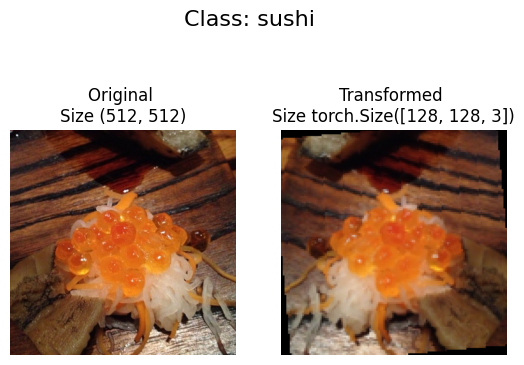

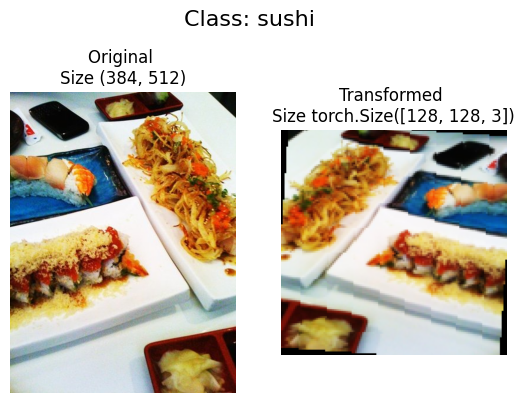

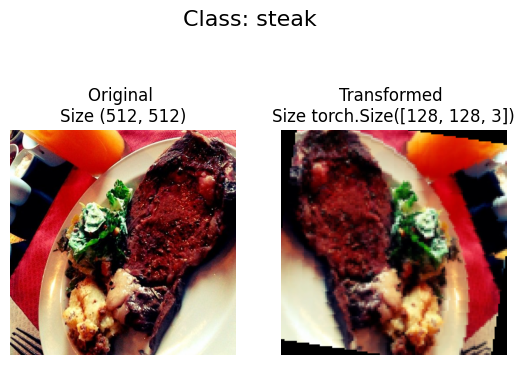

In [26]:
plot_transformed_images(image_path, simp_aug_transform)

In [28]:
train_dl_simp_aug, test_dl_simp_aug, train_data, test_data= data_preprocessing(image_path,
                                                                             train_transform= simp_aug_transform,
                                                                              test_transform=simple_transform)

custom_model_02= Custom_CNN(input_shape=3, hidden_units=10,
                 output_shape= len(train_data.classes)).to(device)


torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS= 100

#Setup loss funct. and optimizer
loss_fn= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(params=custom_model_02.parameters(), lr=1e-4)

from timeit import default_timer as timer
start_time= timer()

model_2_results= train(model=custom_model_02,
                       train_dataloader=train_dl_simp_aug,
                       test_dataloader=test_dl_simp_aug,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs= NUM_EPOCHS)

end_time= timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

Creating DataLoader with batch size 32 and 2 workers
10Epoch: 1 | train_loss: 1.0934 | train_acc: 42.5781 | test_loss: 1.1037 | test_acc: 26.0417
10Epoch: 11 | train_loss: 1.0876 | train_acc: 42.5781 | test_loss: 1.1301 | test_acc: 26.0417
10Epoch: 21 | train_loss: 1.0834 | train_acc: 42.5781 | test_loss: 1.1262 | test_acc: 26.0417
10Epoch: 31 | train_loss: 1.1068 | train_acc: 28.1250 | test_loss: 1.0787 | test_acc: 54.1667
10Epoch: 41 | train_loss: 1.0926 | train_acc: 30.8594 | test_loss: 1.0946 | test_acc: 25.9470
10Epoch: 51 | train_loss: 1.0111 | train_acc: 54.6875 | test_loss: 1.0657 | test_acc: 32.1023
10Epoch: 61 | train_loss: 0.9149 | train_acc: 54.6875 | test_loss: 1.0653 | test_acc: 42.4242
10Epoch: 71 | train_loss: 0.8207 | train_acc: 68.3594 | test_loss: 1.0371 | test_acc: 40.3409
10Epoch: 81 | train_loss: 0.8720 | train_acc: 55.0781 | test_loss: 1.0075 | test_acc: 45.3598
10Epoch: 91 | train_loss: 0.7824 | train_acc: 66.7969 | test_loss: 1.0169 | test_acc: 49.5265
Total tr

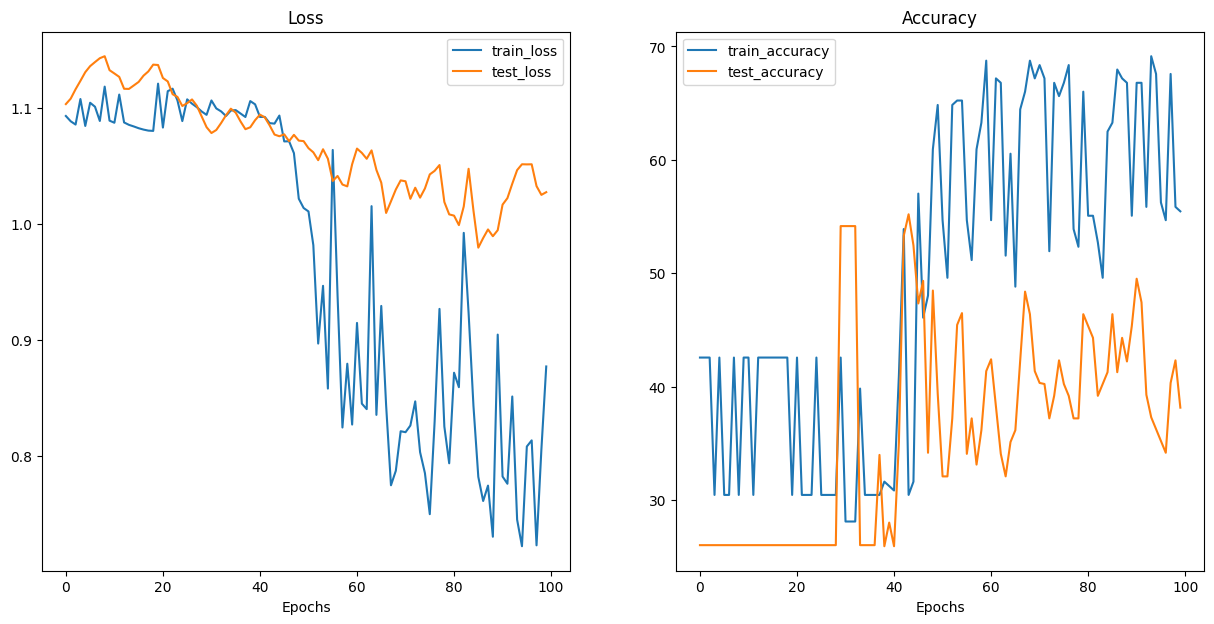

In [29]:
plot_loss_curves(model_2_results)

## Case 3: Implementing TrivialAugmentWide

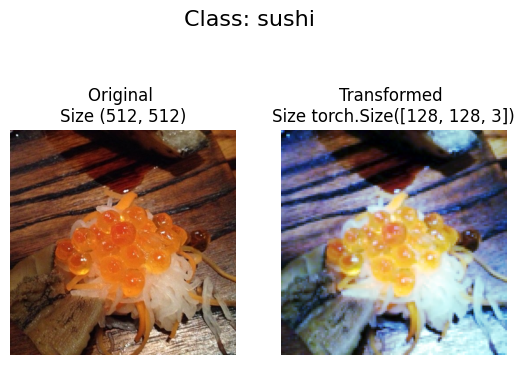

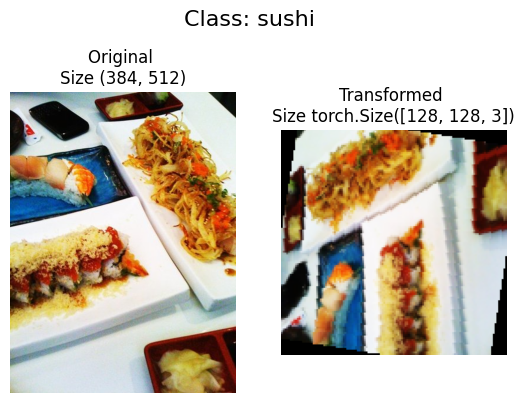

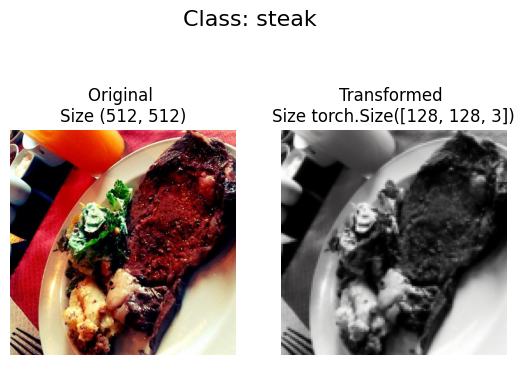

In [31]:
plot_transformed_images(image_path, transform_trivial_augment)

In [32]:
train_dl_aug, test_dl_aug, train_data, test_data= data_preprocessing(image_path,
                                                                             train_transform= transform_trivial_augment,
                                                                              test_transform=simple_transform)

custom_model_03= Custom_CNN(input_shape=3, hidden_units=10,
                 output_shape= len(train_data.classes)).to(device)


torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS= 100

#Setup loss funct. and optimizer
loss_fn= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(params=custom_model_03.parameters(), lr=1e-4)

from timeit import default_timer as timer
start_time= timer()

model_3_results= train(model=custom_model_03,
                       train_dataloader=train_dl_aug,
                       test_dataloader=test_dl_aug,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs= NUM_EPOCHS)

end_time= timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

Creating DataLoader with batch size 32 and 2 workers
10Epoch: 1 | train_loss: 1.1026 | train_acc: 28.1250 | test_loss: 1.0929 | test_acc: 54.1667
10Epoch: 11 | train_loss: 1.0913 | train_acc: 42.5781 | test_loss: 1.1154 | test_acc: 26.0417
10Epoch: 21 | train_loss: 1.0818 | train_acc: 42.5781 | test_loss: 1.1208 | test_acc: 26.0417
10Epoch: 31 | train_loss: 1.0724 | train_acc: 58.9844 | test_loss: 1.0808 | test_acc: 43.2765
10Epoch: 41 | train_loss: 1.0218 | train_acc: 62.8906 | test_loss: 1.0460 | test_acc: 42.3295
10Epoch: 51 | train_loss: 0.9179 | train_acc: 58.5938 | test_loss: 1.0361 | test_acc: 33.2386
10Epoch: 61 | train_loss: 1.0098 | train_acc: 51.9531 | test_loss: 1.0282 | test_acc: 45.4545
10Epoch: 71 | train_loss: 0.8604 | train_acc: 64.4531 | test_loss: 1.0285 | test_acc: 41.3826
10Epoch: 81 | train_loss: 0.8870 | train_acc: 56.2500 | test_loss: 0.9936 | test_acc: 42.3295
10Epoch: 91 | train_loss: 0.9020 | train_acc: 53.5156 | test_loss: 1.0276 | test_acc: 48.4848
Total tr

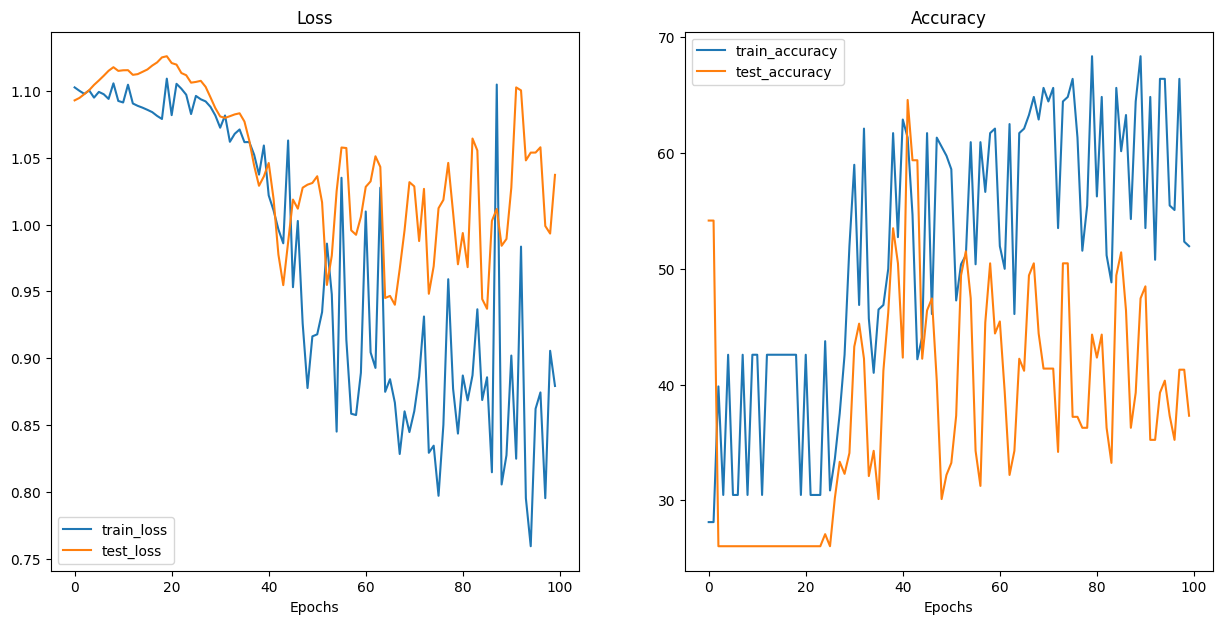

In [33]:
plot_loss_curves(model_3_results)

### Guess transfer learning is the solution at this point